HW-1

Aim: Using Fitts' law and steering law to model input data.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import os
import math

We will read both the CSV files and print the first 5 data points. Our column of interest is "distance", "width", and "movement_time".

In [20]:
df_fl = pd.read_csv("gdrive/MyDrive/25_FL.csv")
df_sl = pd.read_csv("gdrive/MyDrive/25_SL.csv")
df_fl.head(5)

,Unnamed: 0,distance,width,movement_time
0,1719,40,8,488
1,206,210,6,936
2,2371,210,20,843
3,2293,40,6,443
4,2575,120,8,1007


In [21]:
df_sl.head(5)

,Unnamed: 0,distance,width,movement_time
0,117,600,80,426
1,540,600,40,597
2,99,200,25,287
3,202,700,80,630
4,167,500,25,890


The below for loop checks if the distance is zero. This will help us identify which formula can we use for calculating the ID. If the distance is not zero, we can use both the formulas for ID and check the errors/loss respectively.

In [22]:
for i in df_fl['distance']:
  if(i<=0):print("Error")

Next step is to calculate ID for Fitt's law and Steering law.

In [23]:
# ID_fl = [[math.log(2*(D/W))] for D, W in zip(df_fl['distance'], df_fl['width'])]
ID_fl = [[math.log(D/W+1)] for D, W in zip(df_fl['distance'], df_fl['width'])]
ID_sl = [[D/W] for D, W in zip(df_sl['distance'], df_sl['width'])]

X_fl = ID_fl
df_fl["movement_time"] = df_fl.groupby(["distance", "width"])["movement_time"].transform("mean")
y_fl = df_fl['movement_time']

X_sl = ID_sl
df_sl["movement_time"] = df_sl.groupby(["distance", "width"])["movement_time"].transform("mean")
y_sl = df_sl['movement_time']

reg_fl = LinearRegression().fit(X_fl, y_fl)
reg_sl = LinearRegression().fit(X_sl, y_sl)
print("For FL.csv")
print("slope :", reg_fl.coef_[0], "intercept :", reg_fl.intercept_)
print("For SL.csv")
print("slope :", reg_sl.coef_[0], "intercept :", reg_sl.intercept_)

For FL.csv
slope : 258.8248592719121 intercept : 134.78951530482277
For SL.csv
slope : 35.02776562825219 intercept : 66.02477790630297


In [24]:
slope_fl = reg_fl.coef_[0]
intercept_fl = reg_fl.intercept_
y_pred_fl = intercept_fl + slope_fl * np.array([id[0] for id in ID_fl])

slope_sl = reg_sl.coef_[0]
intercept_sl = reg_sl.intercept_
y_pred_sl = intercept_sl + slope_sl * np.array([id[0] for id in ID_sl])

In [25]:
R2_fl = r2_score(y_fl, y_pred_fl)
MSE_fl = mean_squared_error(y_fl, y_pred_fl)
RMSE_fl = np.sqrt(MSE_fl)
print("For FL.csv")
print("R\u00b2 value: ", R2_fl)
print("Root Mean Squared Error (RMSE): ", RMSE_fl)

R2_sl = r2_score(y_sl, y_pred_sl)
MSE_sl = mean_squared_error(y_sl, y_pred_sl)
RMSE_sl = np.sqrt(MSE_sl)
print("For SL.csv")
print("R\u00b2 value: ", R2_sl)
print("Root Mean Squared Error (RMSE): ", RMSE_sl)

For FL.csv
R² value:  0.9831894394832282
Root Mean Squared Error (RMSE):  21.40251097401533
For SL.csv
R² value:  0.9075053456545924
Root Mean Squared Error (RMSE):  85.63891091806448


For Fitts' law, here we can see if $ID = \log(\frac{D}{W}+1)$, we get better $R^2$ and RMSE, than compared to when $ID = \log(\frac{2D}{W})$.

For Steering law we use $ID = \frac{D}{W}$.



<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-578820240.py:7: SyntaxWarning: invalid escape sequence '\c'
  plt.text(1.2, 900, f"y = {'{:.2f}'.format(intercept_fl)} + {'{:.2f}'.format(slope_fl)} $\cdot$ x")


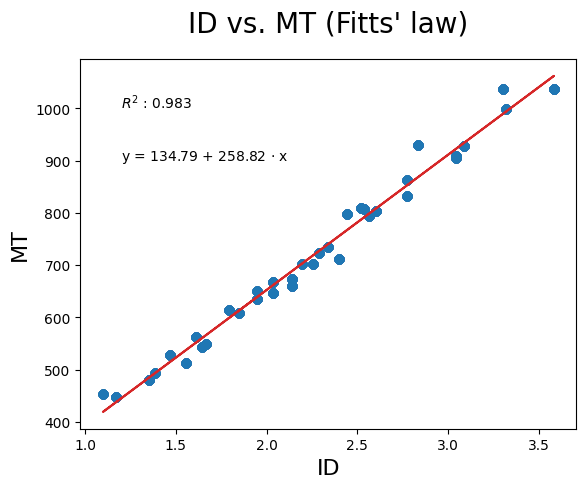

In [31]:
plt.scatter(np.array([id[0] for id in ID_fl]), y_fl, c = "tab:blue")
plt.plot(np.array([id[0] for id in ID_fl]), y_pred_fl, c = "tab:red")
plt.title("ID vs. MT (Fitts' law)", fontsize=20, pad=20)
plt.xlabel("ID", fontsize=16)
plt.ylabel("MT", fontsize=16)
plt.text(1.2, 1000, r"$R^2$ : " + '{:.3f}'.format(R2_fl))
plt.text(1.2, 900, f"y = {'{:.2f}'.format(intercept_fl)} + {'{:.2f}'.format(slope_fl)} $\cdot$ x")
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-490534246.py:7: SyntaxWarning: invalid escape sequence '\c'
  plt.text(4, 1200, f"y = {'{:.2f}'.format(intercept_sl)} + {'{:.2f}'.format(slope_sl)} $\cdot$ x")


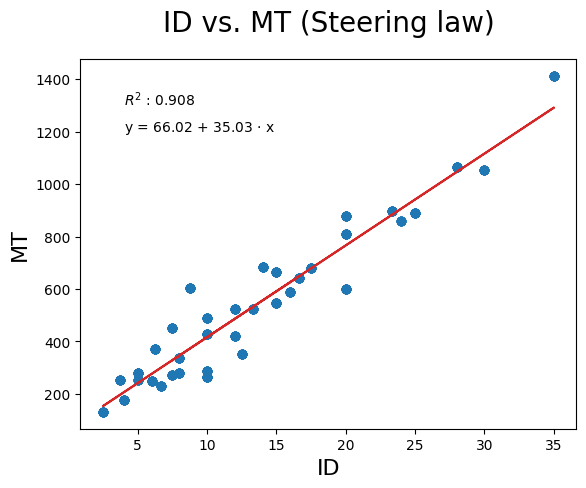

In [32]:
plt.scatter(np.array([id[0] for id in ID_sl]), y_sl, c = "tab:blue")
plt.plot(np.array([id[0] for id in ID_sl]), y_pred_sl, c = "tab:red")
plt.title("ID vs. MT (Steering law)", fontsize=20, pad=20)
plt.xlabel("ID", fontsize=16)
plt.ylabel("MT", fontsize=16)
plt.text(4, 1300, r"$R^2$ : " + '{:.3f}'.format(R2_sl))
plt.text(4, 1200, f"y = {'{:.2f}'.format(intercept_sl)} + {'{:.2f}'.format(slope_sl)} $\cdot$ x")
plt.show()

Observations:

Here the linear regression model closely follows the experimental data, and we can verify this with the ID vs MT graph for both Fitt's law and Steering law.

Also, the coefficient of determination ($R^2$) shows good it fits (closer to 1 is better). RMSE shows the model prediction error (closer to 0 is better).

Conclusion:

These results confirm that both Fitts' law and Steering law provides a reliable linear model for predicting movement time based on index of difficulty.